In [1]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
 
# ============================================================
#  1. PREPROCESSING (par chunks, sur tout le fichier)
# ============================================================
from preprocess import preprocess_pipeline
 
mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
                'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
                'fat_100g', 'carbohydrates_100g']
 
preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,       # lit le csv 100 000 lignes à la fois
    missing_threshold=50,
    features=mes_features
)
 
print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

(758485, 7)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g
716939,1855.6,5.1,27.2,0.8000,5.8,22.4,54.6
576959,272.0,0.0,16.0,0.0000,0.0,0.0,16.0
416885,1705.9,1.6,3.1,1.0825,12.0,5.9,74.0
1186649,2936.0,6.8,3.1,0.0100,14.3,68.1,5.1
260278,1024.7,7.7,6.1,1.4000,15.0,18.0,6.1


In [2]:
# ============================================================
#  2. OUTLIERS — on récupère X et y, on regarde, on nettoie
# ============================================================
from outliers import apply_impossible_drop, identify_impossible
 
# on récupère X, y ET X_inconnu (pour la prédiction finale)
X_train = preprocess_full["X_train"]
y_train = preprocess_full["y_train"]
X_test  = preprocess_full["X_test"]
y_test  = preprocess_full["y_test"]
X_inconnu = preprocess_full["X_inconnu"]
 
# on REGARDE d'abord quelles lignes sont impossibles
lignes_impossibles, comptes = identify_impossible(X_train)
print("Nombre de valeurs impossibles par colonne :")
for col, n in comptes.items():
    print(f"  {col} : {n}")
print(f"\nLignes impossibles à supprimer : {lignes_impossibles.sum()}")
print("\nVoici ces lignes (les valeurs impossibles) :")
print(X_train[lignes_impossibles])
 
# puis on SUPPRIME (seulement sur le train, X et y restent alignés)
avant = len(X_train)
X_train, y_train = apply_impossible_drop(X_train, y_train)
print(f"\n{avant - len(X_train)} ligne(s) impossible(s) retirée(s)")
print("X_train :", X_train.shape, "| y_train :", len(y_train))

Nombre de valeurs impossibles par colonne :
  energy_100g : 391
  saturated-fat_100g : 70
  sugars_100g : 1985
  salt_100g : 319
  proteins_100g : 607
  fat_100g : 177
  carbohydrates_100g : 325

Lignes impossibles à supprimer : 2805

Voici ces lignes (les valeurs impossibles) :
         energy_100g  saturated-fat_100g   sugars_100g   salt_100g  \
1257444  1173.000000            3.100000  13228.603518    1.200000   
1273775   866.000000            4.700000  13228.603518    1.300000   
1366524  2677.700000            1.800000      1.400000    0.070000   
1138002  3404.000000           14.000000  13228.603518    0.000000   
274250   1175.762000            5.510514  13228.603518    0.003275   
...              ...                 ...           ...         ...   
790074   1175.762000            5.510514  13228.603518    0.003575   
1188575  1921.560000           13.300000      2.170000  110.000000   
13224    1461.904762           16.666667  13228.603518    2.503571   
218134   6800.000000

In [3]:
# ============================================================
#  3. ÉCHANTILLON de 35000 pour ENTRAÎNER plus vite
#     (seulement sur le train ; le test reste entier)
# ============================================================
TAILLE = 35000
 
if len(X_train) > TAILLE:
    X_train = X_train.sample(TAILLE, random_state=42)
    y_train = y_train.loc[X_train.index]   # y aligné avec X
 
print("Entraînement sur :", X_train.shape)
print("Répartition des classes dans l'échantillon :")
print(y_train.value_counts())
print("\nTest sur :", X_test.shape)
 
 
# ============================================================
#  4. MODÈLE — RandomForest + Optuna  (ton code, inchangé)
# ============================================================
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
 
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
def objective(trial):
    # Espace de recherche des hyperparamètres
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 10, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 30)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
 
    # Création du modèle avec les hyperparamètres suggérés
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
 
    # Evaluation par cross-validation
    score = cross_val_score(model, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1)
    return score.mean()
 
# Création de l'étude (on veut maximiser le f1_macro)
study = optuna.create_study(direction="maximize")
 
# Lancement de l'optimisation (50 essais)
study.optimize(objective, n_trials=50, show_progress_bar=True)
 
# Résultats
print(f"Meilleurs hyperparamètres: {study.best_params}")
print(f"Meilleur f1_macro: {study.best_value:.4f}")

Entraînement sur : (35000, 7)
Répartition des classes dans l'échantillon :
nutriscore_grade
e    9089
d    9000
c    7695
a    5055
b    4161
Name: count, dtype: int64

Test sur : (275333, 7)


c:\Users\Alina\Desktop\AMU\DESU Data science\DESU_ROCHET\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 8. Best value: 0.800134: 100%|██████████| 50/50 [06:39<00:00,  8.00s/it]

Meilleurs hyperparamètres: {'n_estimators': 477, 'max_depth': 18, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': None}
Meilleur f1_macro: 0.8001


              precision    recall  f1-score   support

           a       0.79      0.54      0.64     40092
           b       0.71      0.45      0.55     31680
           c       0.77      0.59      0.67     57363
           d       0.86      0.61      0.71     69425
           e       0.54      0.94      0.69     76773

    accuracy                           0.67    275333
   macro avg       0.73      0.63      0.65    275333
weighted avg       0.72      0.67      0.67    275333

Accuracy test : 0.6702


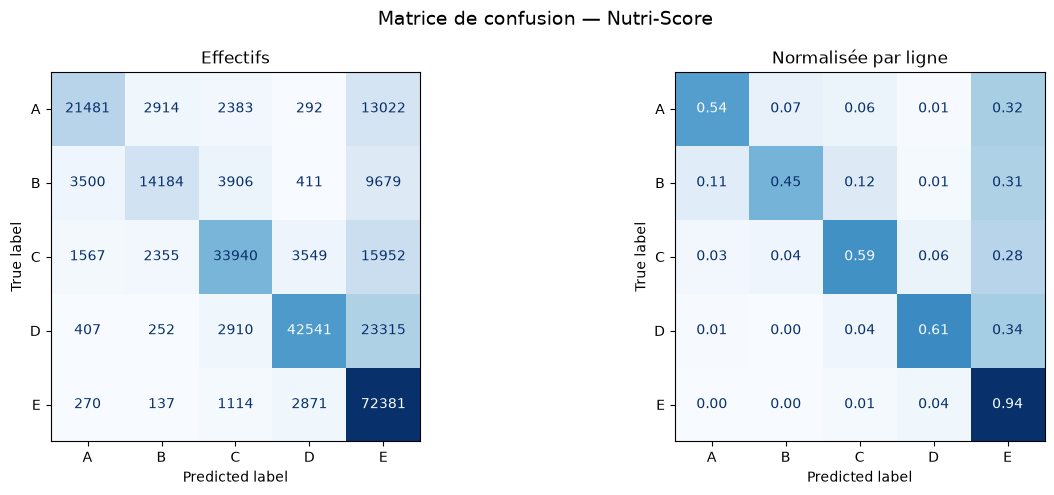

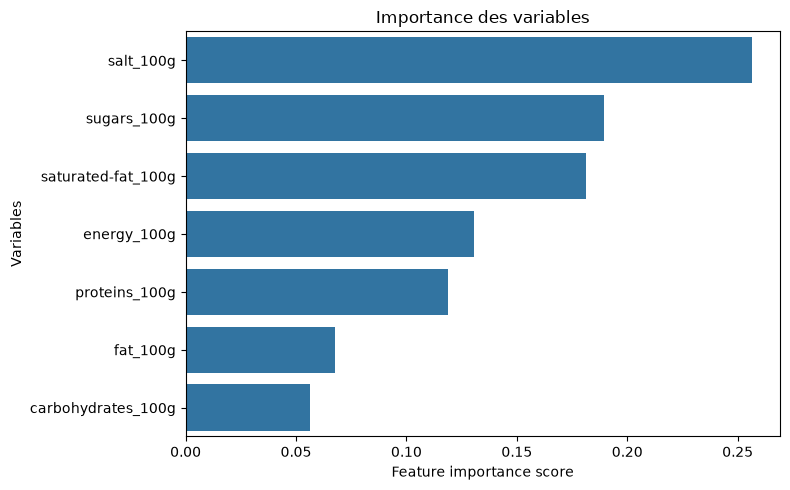

salt_100g             0.256349
sugars_100g           0.189272
saturated-fat_100g    0.181438
energy_100g           0.130391
proteins_100g         0.118659
fat_100g              0.067508
carbohydrates_100g    0.056382
dtype: float64


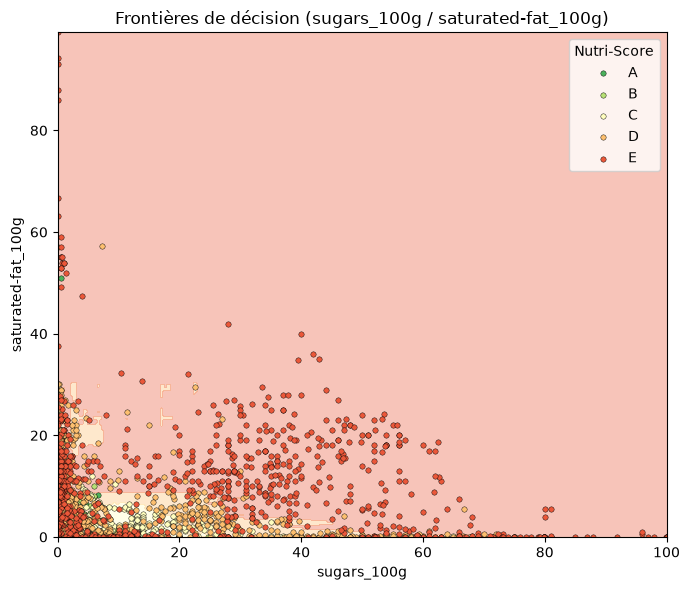

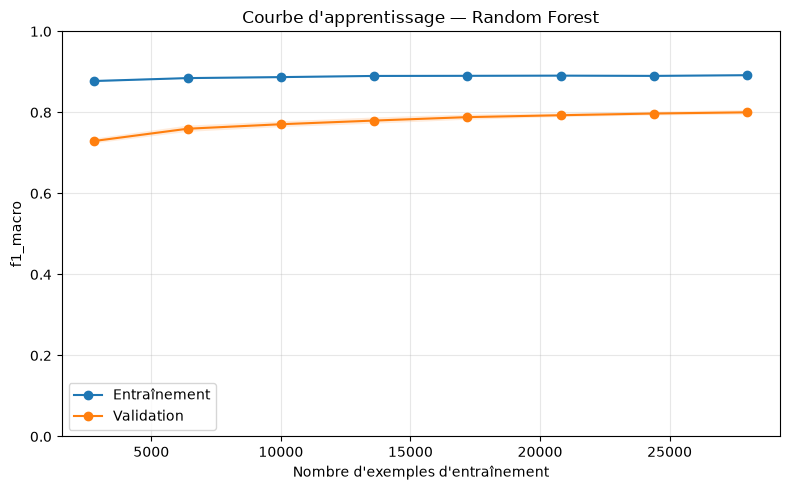

X_train : 35000
X_test  : 275333


In [ ]:
# ============================================================
#  5. ÉVALUATION du meilleur modèle  (ton code, inchangé)
# ============================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
 
best_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)
 
y_pred = best_model.predict(X_test)
 
print(classification_report(y_test, y_pred))
print(f"Accuracy test : {best_model.score(X_test, y_test):.4f}")
 
 
# --- Matrice de confusion ---
labels = sorted(y_train.unique())
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Effectifs")
 
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", normalize="true", values_format=".2f",
    ax=axes[1], colorbar=False
)
axes[1].set_title("Normalisée par ligne")
 
fig.suptitle("Matrice de confusion — Nutri-Score", fontsize=14)
plt.tight_layout()
plt.show()
 
 
# --- Importance des variables ---
feature_scores = pd.Series(best_model.feature_importances_,
                           index=X_train.columns).sort_values(ascending=False)
 
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel("Feature importance score")
plt.ylabel("Variables")
plt.title("Importance des variables")
plt.tight_layout()
plt.show()
 
print(feature_scores)
 
 
# --- Graphiques Optuna ---
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_parallel_coordinate(study).show()


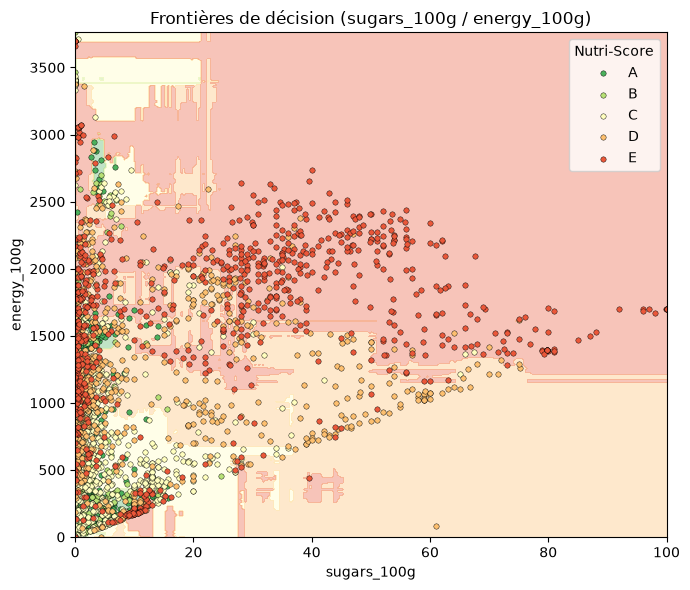

In [8]:
 
# --- Frontières de décision (ton code, inchangé) ---
from matplotlib.colors import ListedColormap
 
def plot_decision_regions(X_df, y_ser, classifier,
                          features=("sugars_100g", "energy_100g"),
                          figsize=(7, 6), n_grid=300, sample=3000):
    f0, f1 = features
    d = pd.concat([X_df[[f0, f1]], y_ser], axis=1)
    if len(d) > sample:
        d = d.sample(sample, random_state=42)
    X2, y2 = d[[f0, f1]], d[y_ser.name]
 
    classes = sorted(y2.unique())
    idx = {c: i for i, c in enumerate(classes)}
 
    clf = classifier.fit(X2, y2)
 
    x_min, x_max = X2[f0].min(), X2[f0].max()
    y_min, y_max = X2[f1].min(), X2[f1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid),
                         np.linspace(y_min, y_max, n_grid))
 
    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[f0, f1])
    Z = pd.Series(clf.predict(grid)).map(idx).values.reshape(xx.shape)
 
    cmap = ListedColormap(sns.color_palette("RdYlGn_r", len(classes)).as_hex())
 
    fig, ax = plt.subplots(figsize=figsize)
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.35, levels=np.arange(-0.5, len(classes)))
 
    for c in classes:
        m = y2 == c
        ax.scatter(X2.loc[m, f0], X2.loc[m, f1], color=cmap(idx[c]),
                   label=c.upper(), edgecolor="black", linewidth=0.3, s=15)
 
    ax.set_xlabel(f0)
    ax.set_ylabel(f1)
    ax.set_title(f"Frontières de décision ({f0} / {f1})")
    ax.legend(title="Nutri-Score")
    plt.tight_layout()
    plt.show()
 
plot_decision_regions(
    X_train, y_train,
    RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
)

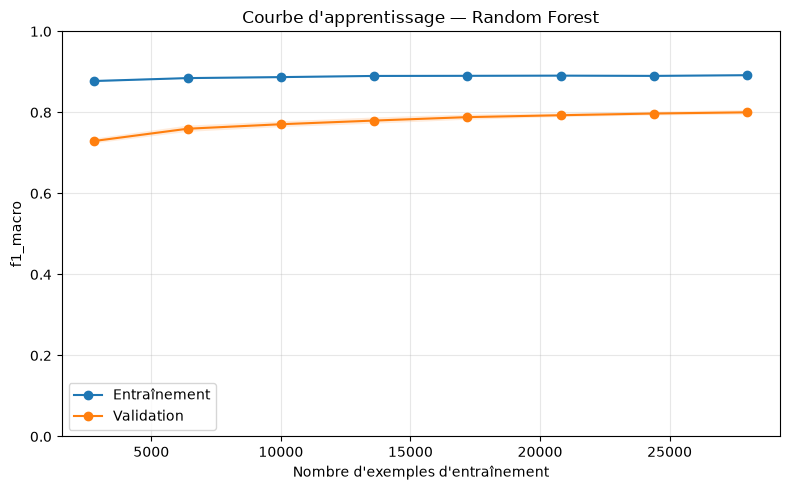

X_train : 35000
X_test  : 275333


In [10]:
# --- Courbe d'apprentissage (ton code, inchangé) ---
from sklearn.model_selection import learning_curve
 
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring="f1_macro", n_jobs=-1, random_state=42
)
 
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)
 
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Entraînement")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, "o-", label="Validation")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("f1_macro")
plt.ylim(0, 1)   # force l'axe vertical de 0 à 1
plt.title("Courbe d'apprentissage — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
print("X_train :", len(X_train))
print("X_test  :", len(X_test))


In [11]:
# ============================================================
#  6. PRÉDICTION sur le dataset INCONNU (le but final)
# ============================================================
print("Aliments à prédire (inconnu) :", X_inconnu.shape)
 
# on prédit le nutriscore des aliments qui n'en avaient pas
predictions_inconnu = best_model.predict(X_inconnu)
 
X_inconnu_avec_pred = X_inconnu.copy()
X_inconnu_avec_pred["nutriscore_predit"] = predictions_inconnu
 
print("\nRépartition des nutriscores prédits :")
print(X_inconnu_avec_pred["nutriscore_predit"].value_counts())
 
X_inconnu_avec_pred.head(10)


Aliments à prédire (inconnu) : (1320742, 7)

Répartition des nutriscores prédits :
nutriscore_predit
e    419138
d    389091
c    275914
a    139264
b     97335
Name: count, dtype: int64


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_predit
604,9.000000,3.600000,4.900000,1.795091,17.500000,10.200000,22.500000,d
605,856.000000,3.400000,1.900000,0.700000,5.900000,12.100000,18.100000,c
606,2770.000000,16.129032,3.225806,0.524194,19.677419,54.838710,19.354839,d
712,2221.960000,19.300000,37.720000,0.270000,5.680000,30.280000,59.120000,e
744,1982.000000,11.000000,65.000000,0.120000,5.700000,19.000000,69.000000,e
750,238.600000,0.400000,1.200000,1.795091,1.400000,0.600000,11.000000,c
751,57.341464,5.510514,13228.603518,1.795091,0.292683,0.268293,2.439024,d
762,733.478261,4.956522,0.521739,0.530435,15.652174,11.304348,2.521739,c
770,1395.950000,1.110000,18.170000,0.000000,6.780000,8.300000,57.270000,c
773,2533.000000,4.000000,4.750000,2.018750,27.500000,50.000000,7.500000,d
